In [ ]:
import pandas as pd
ds = pd.read_csv('online_retail.csv',encoding='ISO-8859-1')

In [ ]:
ds.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
ds.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
ds.size

4335272

In [ ]:
ds = ds.dropna(subset=['CustomerID'])

In [ ]:
ds = ds[ds['Quantity']> 0]

In [ ]:
ds.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
ds['TotalSpend'] = ds['Quantity']+ ds['UnitPrice']

In [ ]:
ds['InvoiceDate'] = pd.to_datetime(ds['InvoiceDate'])
snapshot_date = ds['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = ds.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo' : 'nunique',
    'TotalSpend': 'sum'
})
rfm.columns = ['Recency', 'Frequency','Monetary']

In [ ]:
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()
rfm_scaled = Scaler.fit_transform(rfm)

rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

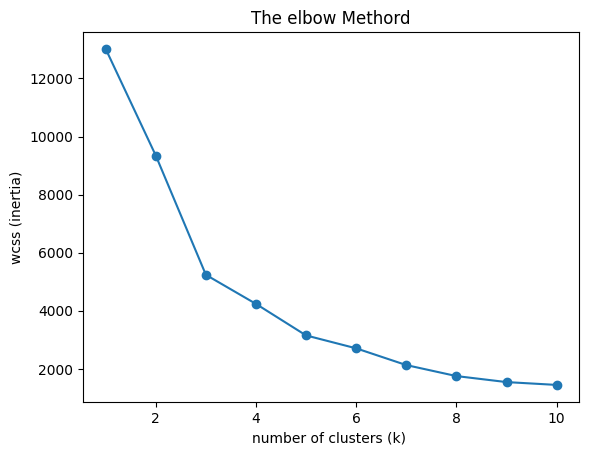

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(rfm_scaled_df)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss, marker='o')
plt.title('The elbow Methord')
plt.xlabel('number of clusters (k) ')
plt.ylabel('wcss (inertia)')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)
print(rfm['Cluster'].value_counts())

Cluster
0    3227
1    1087
2      25
Name: count, dtype: int64


In [ ]:
cluster_profile = rfm.groupby('Cluster').mean()
print(cluster_profile)

            Recency  Frequency      Monetary
Cluster                                     
0         41.243880   4.698482   1423.546756
1        246.431463   1.579577    386.116450
2         18.880000  66.280000  56328.106000


In [ ]:
cluster_map = {0 : 'casual/Regular',
               1: 'At Risk/Churn',
               2: 'VIP / Whales'
               }

rfm['customer_segment'] = rfm['Cluster'].map(cluster_map)

print(rfm[['Recency','Frequency', 'Monetary', 'customer_segment']].head())

            Recency  Frequency  Monetary customer_segment
CustomerID                                               
12346.0         326          1  74216.04     VIP / Whales
12347.0           2          7   2939.21   casual/Regular
12348.0          75          4   2519.71   casual/Regular
12349.0          19          1   1236.10   casual/Regular
12350.0         310          1    262.30    At Risk/Churn


In [72]:
import numpy as np
rfm['Churn'] = np.where(rfm['customer_segment'] =='At Risk/Churn', 1,0)

print(rfm['Churn'].value_counts())

Churn
0    3252
1    1087
Name: count, dtype: int64


In [74]:
from sklearn.model_selection import train_test_split

x= rfm[['Recency', 'Frequency', 'Monetary']]
y= rfm['Churn']

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

print(f'train data amount: {x_train.shape[0]}')
print(f'test data amount: {x_test.shape[0]}')

train data amount: 3471
test data amount: 868


In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(f'Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')

print(f"Classification Report:\n{classification_report(y_test, y_pred)}")


Model Accuracy: 99.88%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       651
           1       1.00      1.00      1.00       217

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



In [77]:
import pickle
with open('Churn_model.pkl', 'wb') as model_file:
  pickle.dump(model, model_file)

print('model saved successfully')

model saved successfully
